In [7]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Add the src directory to sys.path
src_path = Path.cwd().parent / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))


In [10]:
from gds_loader import GDSLoader
from structure import StructureManager
from poisson import PoissonSolver
import visualizer as vis


# GDS Loader test

In [12]:
gds_path = Path.cwd().parent / "work" / "config" / "T-junction" / "T-junction.gds"

loader = GDSLoader(
    gds_path=str(gds_path),
    gds_unit=1e-6,
    origin=(0.0, 0.0),
    cell_name=None,
)

# Show available layers
layers = loader.get_available_layers()
print("Available layers (layer, datatype):")
for layer, datatype in layers:
    bbox = loader.get_bounding_box(layer, datatype)
    if bbox:
        x_min, y_min, x_max, y_max = bbox
        print(f"  Layer {layer}, datatype {datatype}: "
              f"bbox = ({x_min*1e9:.1f}, {y_min*1e9:.1f}) to ({x_max*1e9:.1f}, {y_max*1e9:.1f}) nm")

Available layers (layer, datatype):
  Layer 0, datatype 0: bbox = (0.0, 0.0) to (560.0, 630.0) nm
  Layer 1, datatype 0: bbox = (5.0, 105.0) to (350.0, 265.0) nm
  Layer 2, datatype 0: bbox = (75.0, 105.0) to (420.0, 265.0) nm
  Layer 3, datatype 0: bbox = (145.0, 105.0) to (490.0, 265.0) nm
  Layer 4, datatype 0: bbox = (215.0, 105.0) to (560.0, 265.0) nm
  Layer 5, datatype 0: bbox = (308.0, 280.0) to (468.0, 625.0) nm
  Layer 6, datatype 0: bbox = (308.0, 350.0) to (468.0, 415.0) nm
  Layer 7, datatype 0: bbox = (308.0, 420.0) to (468.0, 485.0) nm
  Layer 8, datatype 0: bbox = (308.0, 490.0) to (468.0, 555.0) nm


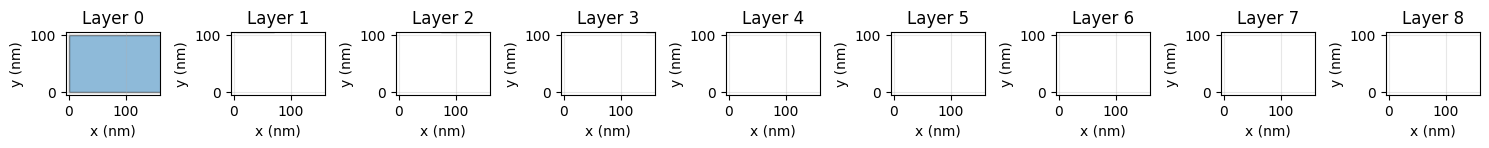

In [21]:
fig, axes = plt.subplots(1, 9, figsize=(15, 5))


for idx, (layer, datatype) in enumerate(layers):
    ax = axes[idx]
    polygons = loader.get_polygons(layer, datatype)
    
    for poly in polygons:
        # Convert to nm for display
        poly_nm = poly * 1e9
        # Close the polygon by repeating the first point
        poly_closed = np.vstack([poly_nm, poly_nm[0]])
        ax.fill(poly_closed[:, 0], poly_closed[:, 1], 
                alpha=0.5, edgecolor='black', linewidth=1)
    
    ax.set_xlabel("x (nm)")
    ax.set_ylabel("y (nm)")
    ax.set_title(f"Layer {layer}")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 160)
    ax.set_ylim(-5, 105)

plt.tight_layout()
plt.show()

In [24]:
layers

[(np.int64(0), np.int64(0)),
 (np.int64(1), np.int64(0)),
 (np.int64(2), np.int64(0)),
 (np.int64(3), np.int64(0)),
 (np.int64(4), np.int64(0)),
 (np.int64(5), np.int64(0)),
 (np.int64(6), np.int64(0)),
 (np.int64(7), np.int64(0)),
 (np.int64(8), np.int64(0))]

In [27]:
loader.get_polygons(2, datatype=0)

[array([[7.50e-08, 1.05e-07],
        [7.50e-08, 2.65e-07],
        [1.40e-07, 2.65e-07],
        [1.40e-07, 1.05e-07]]),
 array([[3.55e-07, 1.05e-07],
        [3.55e-07, 2.65e-07],
        [4.20e-07, 2.65e-07],
        [4.20e-07, 1.05e-07]])]

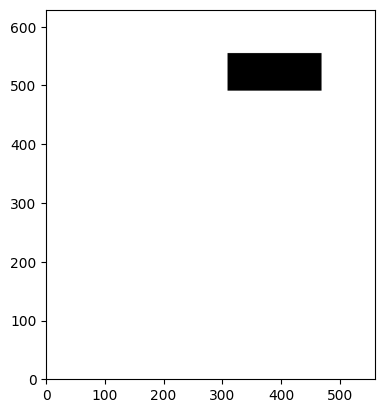

In [39]:
x = np.arange(0, 560e-9, 1e-9)
y = np.arange(0, 630e-9, 1e-9)

rusterized = loader.rasterize_layer(
    layer=8,
    datatype=0,
    x_coords=x,
    y_coords=y,
)

plt.imshow(
    rusterized.T,
    extent=(x[0]*1e9, x[-1]*1e9, y[0]*1e9, y[-1]*1e9),
    origin='lower',
    cmap='gray_r'
)

# Initialize from yaml config and gds geometry file

In [44]:
config_path = Path.cwd().parent / "work" / "config" / "T-junction" / "T-junction.yaml"

manager = StructureManager(str(config_path))

x, y, z = manager.get_grid_coordinates()

print("\n" + "=" * 60)
print(manager.get_summary())
print("=" * 60 + "\n")


=== Structure Summary ===
Grid size (nz, nx, ny): (122, 561, 631)
Grid spacing (h): 1.00 nm (isotropic)
Number of layers: 5
Number of electrodes: 1

--- Unique Materials ---
  0. SiO2: εr=3.90, χ=0.900 eV, Eg=9.000 eV
  1. Si: εr=11.70, χ=4.050 eV, Eg=1.120 eV
  2. SiGe0.3: εr=13.10, χ=4.000 eV, Eg=1.050 eV
  3. Strained_Si: εr=11.70, χ=4.050 eV, Eg=1.080 eV

--- Layers ---
  1. SiO2: z=[0.0, -20.0] nm
  2. Si: z=[-20.0, -22.0] nm
  3. SiGe0.3: z=[-22.0, -62.0] nm
  4. Strained_Si: z=[-62.0, -71.0] nm
  5. SiGe0.3: z=[-71.0, -121.0] nm

--- Electrodes ---
  1. electrode_1: V=0.000 V, shape=rectangle



# Electrode patterns
View the electrode layout and voltages

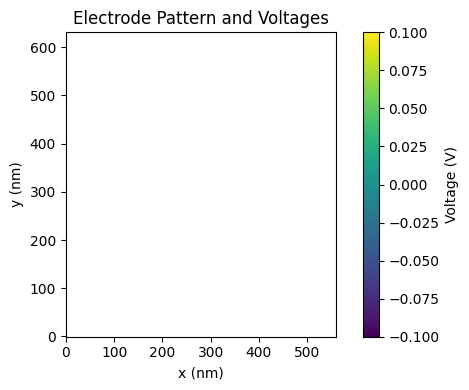

In [49]:
vis.plot_electrode_pattern(
    electrode_mask=manager.electrode_mask,
    electrode_voltages=manager.electrode_voltages,
    x=x,
    y=y,
    z_index=13
)
plt.show()

In [50]:
manager.electrodes

[{'source': 'gds',
  'gds_file': 'T-junction.gds',
  'gds_unit': 1e-06,
  'origin': [0, 0],
  'cell_name': None,
  'layer_mapping': [{'layer': 0,
    'datatype': 0,
    'voltage': 0.01,
    'z_position': -1.2e-08},
   {'layer': 1, 'datatype': 0, 'voltage': 0.02, 'z_position': -1.2e-08},
   {'layer': 2, 'datatype': 0, 'voltage': 0.03, 'z_position': -1.2e-08},
   {'layer': 3, 'datatype': 0, 'voltage': 0.04, 'z_position': -1.2e-08},
   {'layer': 4, 'datatype': 0, 'voltage': 0.05, 'z_position': -1.2e-08},
   {'layer': 5, 'datatype': 0, 'voltage': 0.06, 'z_position': -1.2e-08},
   {'layer': 6, 'datatype': 0, 'voltage': 0.07, 'z_position': -1.2e-08},
   {'layer': 7, 'datatype': 0, 'voltage': 0.08, 'z_position': -1.2e-08},
   {'layer': 8, 'datatype': 0, 'voltage': 0.09, 'z_position': -1.2e-08}]}]